![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje
## Presentado por: Dayana Franco Salcedo



## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [4]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [5]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [6]:
bikes.groupby('season').agg({'temp': 'mean', 'total': 'mean'}).round(2)

,temp,total
season,,
1,12.53,116.34
2,22.82,215.25
3,28.79,234.42
4,16.65,198.99


In [7]:
# Estadísticas completas por season
bikes.groupby('season').total.describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0


In [8]:
# Estadísticas completas por hour
bikes.groupby('hour').total.describe().style\
    .highlight_max(color='lightgreen', axis=0)\
    .highlight_min(color='salmon', axis=0)

,count,mean,std,min,25%,50%,75%,max
hour,,,,,,,,
0,455.000000,55.138462,43.620012,2.000000,24.000000,41.000000,74.500000,283.000000
1,454.000000,33.859031,34.112105,1.000000,11.000000,19.000000,46.000000,168.000000
2,448.000000,22.899554,26.110267,1.000000,5.000000,11.000000,32.000000,119.000000
3,433.000000,11.757506,12.666442,1.000000,3.000000,6.000000,15.000000,66.000000
4,442.000000,6.407240,4.217633,1.000000,3.000000,6.000000,9.000000,28.000000
5,452.000000,19.767699,12.784293,1.000000,8.000000,19.000000,29.000000,57.000000
6,455.000000,76.259341,54.745333,1.000000,24.500000,75.000000,118.000000,213.000000
7,455.000000,213.116484,159.207044,1.000000,63.000000,208.000000,334.000000,596.000000
8,455.000000,362.769231,231.723065,8.000000,133.500000,392.000000,563.500000,839.000000


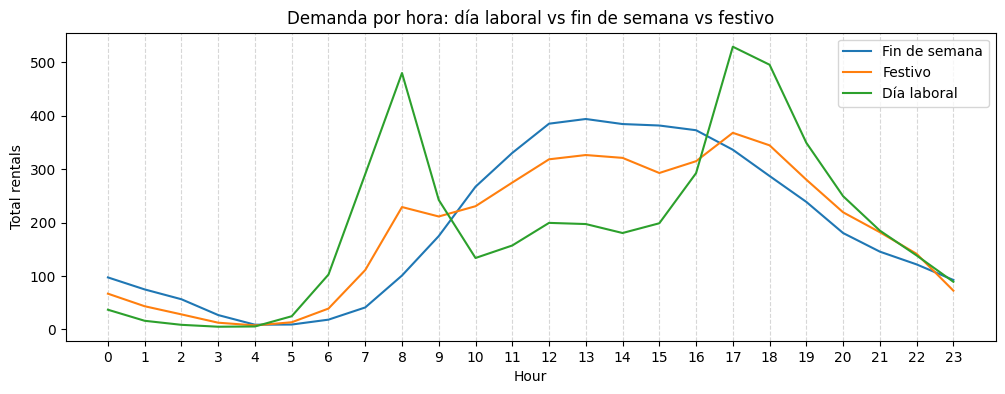

In [22]:
import matplotlib.pyplot as plt
bikes.groupby(['hour', 'workingday', 'holiday']).total.mean().unstack(level=[1,2]).plot(figsize=(12,4))
plt.xlabel('Hour')
plt.ylabel('Total rentals')
plt.title('Demanda por hora: día laboral vs fin de semana vs festivo')
plt.legend(['Fin de semana', 'Festivo', 'Día laboral'])
plt.xticks(range(0, 24, 1))
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

## Inferencia sobre los datos:


**Variable `season`:**

El verano (season=3) presenta la mayor demanda promedio con 234 rentas y un máximo de 977, 
mientras que el invierno (season=1) registra la menor demanda promedio (116 rentas) y el 
menor máximo (801). La alta desviación estándar en todas las temporadas (entre 125 y 197) 
indica gran variabilidad dentro de cada estación. El mínimo de 1 renta se repite en todas 
las temporadas, lo que sugiere que hay horas de muy baja demanda independientemente de la 
época del año.

**Variable `hour`:**

La hora 17 (5pm) presenta la mayor demanda promedio con 469 rentas y la mayor desviación 
estándar (224), seguida por la hora 8am (363 rentas), lo que es consistente con 
desplazamientos laborales de entrada y salida del trabajo. El máximo absoluto del dataset 
se registra a las 18h con 977 rentas. Las horas de madrugada (1am-7am) registran los 
mínimos absolutos de 1 renta y promedios que no superan las 55 rentas, siendo las 4am 
la hora de menor demanda con apenas 6 rentas promedio y un máximo de 28. La alta 
variabilidad en horas pico (std>200) sugiere diferencias importantes entre días laborales 
y fines de semana.

La alta variabilidad en horas pico (std>200) se explica por el comportamiento 
diferenciado según el tipo de día. En días laborales se observan dos picos muy 
marcados a las 8am (490 rentas) y 17h (530 rentas), consistentes con 
desplazamientos al trabajo. En fines de semana la demanda es más uniforme y 
sostenida durante el día (12pm-6pm), sugiriendo uso recreativo. Los días festivos 
presentan un comportamiento intermedio, con un pico moderado en la mañana y 
demanda estable durante el resto del día.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

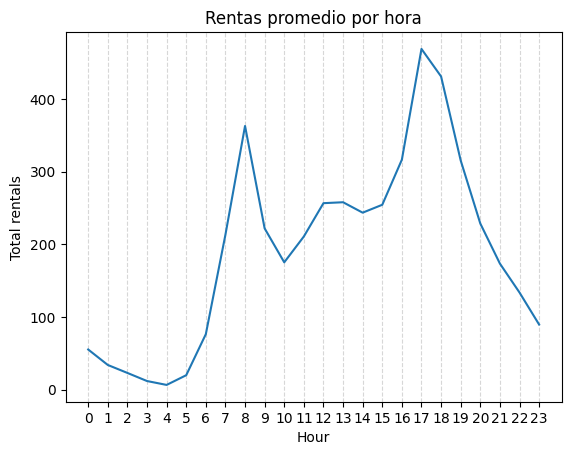

In [10]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()
plt.title('Rentas promedio por hora')
plt.xlabel('Hour')
plt.ylabel('Total rentals')
plt.xticks(range(0, 24, 1))
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

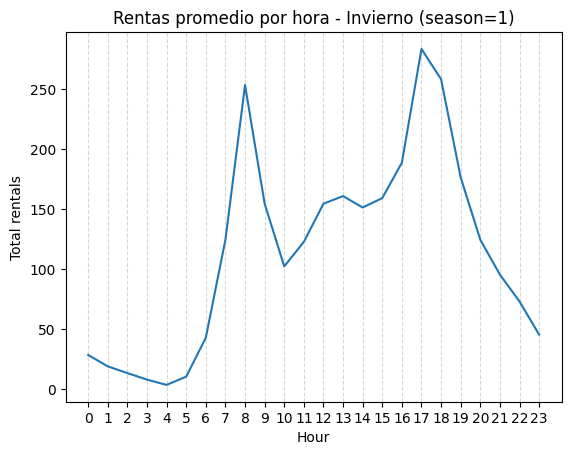

In [11]:
# Celda 2.2 - "season"=1 (invierno)
bikes[bikes['season'] == 1].groupby('hour').total.mean().plot()
plt.title('Rentas promedio por hora - Invierno (season=1)')
plt.xlabel('Hour')
plt.ylabel('Total rentals')
plt.xticks(range(0, 24, 1))
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

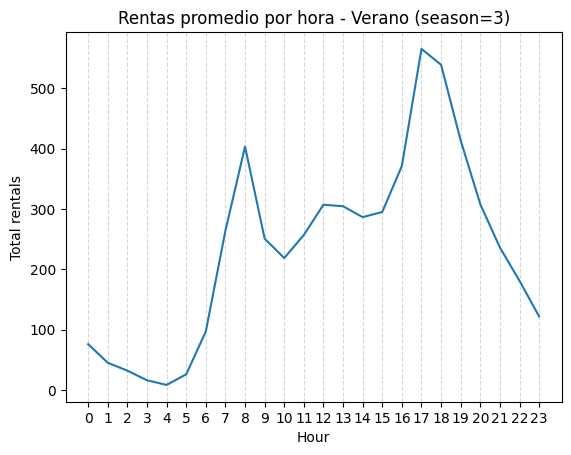

In [12]:
# Celda 2.3 - "season"=3 (verano)
bikes[bikes['season'] == 3].groupby('hour').total.mean().plot()
plt.title('Rentas promedio por hora - Verano (season=3)')
plt.xlabel('Hour')
plt.ylabel('Total rentals')
plt.xticks(range(0, 24, 1))
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

### Hallazgos - Punto 2

**Celda 2.1 - Demanda general por hora:**
Se observan dos picos claros de demanda: hora 8 (370 rentas) y hora 17 (460 rentas), 
consistentes con horarios de desplazamiento laboral. La demanda mínima ocurre 
entre las 3am y 5am con menos de 10 rentas promedio.

**Celda 2.2 - Invierno (season=1):**
El patrón de dos picos se mantiene en hora 8 (255 rentas) y hora 17 (275 rentas), 
pero con valores significativamente menores que el promedio general. El clima frío 
reduce la demanda en todas las horas del día.

**Celda 2.3 - Verano (season=3):**
Los picos son más pronunciados: hora 8 (400 rentas) y hora 17 (550 rentas), 
superando el promedio general. La demanda nocturna también es mayor que en invierno 
(130 rentas vs 50 rentas), lo que sugiere que el clima cálido incentiva el uso 
del servicio en horarios extendidos.

Este patrón de dos picos es más pronunciado en días laborales y se suaviza 
en fines de semana y festivos, como se evidenció en el análisis del Punto 1.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [13]:
# Celda 3
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Crear dummies para season (categórica)
season_dummies = pd.get_dummies(bikes['season'], prefix='season', drop_first=True)

# Unir dummies con hour
X = pd.concat([bikes[['hour']], season_dummies], axis=1)
y = bikes['total']

# División en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

# Ajuste del modelo
lr = LinearRegression()
lr.fit(X_train, y_train)

# Imprimir coeficientes
coef = pd.DataFrame({'variable': X.columns, 'coeficiente': lr.coef_}).sort_values('coeficiente', ascending=False)
print(coef)
print(f'\nIntercepto: {lr.intercept_:.2f}')

   variable  coeficiente
2  season_3   118.740651
1  season_2    93.830184
3  season_4    81.148483
0      hour    10.628063

Intercepto: -6.46


### Interpretación de coeficientes - Punto 3

El modelo de regresión lineal arroja los siguientes coeficientes:

**Variable `hour` (coeficiente: 10.63):**
Por cada hora adicional del día, el número de rentas promedio aumenta en 10.63 
unidades, manteniendo las demás variables constantes. Sin embargo, esto asume 
una relación lineal con la hora, lo cual no refleja bien la realidad dado que 
la demanda tiene dos picos (hora 8 y hora 17) y no crece de forma constante.

**Variable `season_3` - Verano (coeficiente: 118.74):**
En verano se rentan en promedio 118.74 bicicletas más que en invierno 
(categoría de referencia), manteniendo la hora constante.

**Variable `season_2` - Primavera (coeficiente: 93.83):**
En primavera se rentan en promedio 93.83 bicicletas más que en invierno.

**Variable `season_4` - Otoño (coeficiente: 81.18):**
En otoño se rentan en promedio 81.18 bicicletas más que en invierno.


**Limitaciones de la regresión lineal:**
- Asume una relación lineal entre hora y demanda, cuando la realidad muestra 
  dos picos no lineales (hora 8 y hora 17).
- No captura interacciones entre variables, por ejemplo que el efecto de la 
  hora es diferente en verano que en invierno.
- El intercepto negativo (-6.46) no tiene interpretación práctica ya que 
  no pueden existir rentas negativas.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [14]:
# Celda 4
# Árbol manual con al menos 6 nodos finales sobre hour y season

# Nodo raíz - dividir por hour < 10
mask1 = bikes['hour'] < 10

# Rama izquierda (hour < 10) - dividir por hour < 7
mask2 = bikes['hour'] < 7
mask3 = (bikes['hour'] >= 7) & (bikes['hour'] < 10)

# Rama derecha (hour >= 10) - dividir por hour < 17
# Subdividir 10 <= hour < 17 por season
mask4a = (bikes['hour'] >= 10) & (bikes['hour'] < 17) & (bikes['season'] <= 2)
mask4b = (bikes['hour'] >= 10) & (bikes['hour'] < 17) & (bikes['season'] > 2)

# Rama hour >= 17 subdividir por season
mask6 = (bikes['hour'] >= 17) & (bikes['season'] <= 2)
mask7 = (bikes['hour'] >= 17) & (bikes['season'] > 2)

# Imprimir nodos finales con prediccion (promedio de total)
nodos = {
    'hour < 7': bikes[mask2]['total'].mean(),
    '7 <= hour < 10': bikes[mask3]['total'].mean(),
    '10 <= hour < 17 y season <= 2': bikes[mask4a]['total'].mean(),
    '10 <= hour < 17 y season > 2': bikes[mask4b]['total'].mean(),
    'hour >= 17 y season <= 2': bikes[mask6]['total'].mean(),
    'hour >= 17 y season > 2': bikes[mask7]['total'].mean(),
}

for nodo, valor in nodos.items():
    print(f'Nodo: {nodo:40s} -> Prediccion promedio: {valor:.1f} rentas')

Nodo: hour < 7                                 -> Prediccion promedio: 32.6 rentas
Nodo: 7 <= hour < 10                           -> Prediccion promedio: 265.9 rentas
Nodo: 10 <= hour < 17 y season <= 2            -> Prediccion promedio: 211.8 rentas
Nodo: 10 <= hour < 17 y season > 2             -> Prediccion promedio: 278.0 rentas
Nodo: hour >= 17 y season <= 2                 -> Prediccion promedio: 227.9 rentas
Nodo: hour >= 17 y season > 2                  -> Prediccion promedio: 297.8 rentas


### Árbol de decisión manual - Punto 4

Se construyó un árbol de decisión manualmente iterando sobre las variables 
`hour` y `season`, obteniendo 6 nodos finales. La predicción de cada nodo 
corresponde al promedio de rentas de las observaciones que caen en ese nodo.

**Estructura del árbol:**

- **Nodo 1 - hour < 7 (32.6 rentas):** Madrugada, demanda mínima 
  independientemente de la temporada.

- **Nodo 2 - 7 <= hour < 10 (265.9 rentas):** Pico de la mañana asociado 
  a desplazamientos laborales de entrada al trabajo.

- **Nodo 3 - 10 <= hour < 17 y season <= 2 (211.8 rentas):** Mediodía en 
  invierno y primavera, demanda moderada limitada por condiciones climáticas.

- **Nodo 4 - 10 <= hour < 17 y season > 2 (278.0 rentas):** Mediodía en 
  verano y otoño, mayor demanda favorecida por mejores condiciones climáticas.

- **Nodo 5 - hour >= 17 y season <= 2 (227.9 rentas):** Tarde en invierno 
  y primavera, pico vespertino moderado.

- **Nodo 6 - hour >= 17 y season > 2 (297.8 rentas):** Tarde en verano y 
  otoño, mayor pico de demanda del dataset, consistente con clima favorable 
  y horario de salida del trabajo.

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

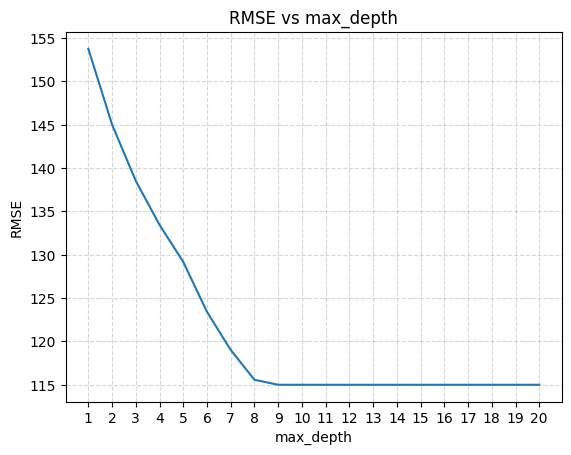

Mejor max_depth: 10
Mejor RMSE arbol: 115.00
RMSE regresion lineal: 162.71


In [15]:
# Celda 5
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Crear dummies para season
season_dummies = pd.get_dummies(bikes['season'], prefix='season', drop_first=True)
X = pd.concat([bikes[['hour']], season_dummies], axis=1)
y = bikes['total']

# División en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

# Calibración de max_depth
max_depth_range = range(1, 21)
rmse_scores = []

for depth in max_depth_range:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=1)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))

# Graficar
plt.plot(max_depth_range, rmse_scores)
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('RMSE vs max_depth')
plt.xticks(range(1, 21))
plt.grid(linestyle='--', alpha=0.5)
plt.show()

# Mejor max_depth
best_depth = max_depth_range[rmse_scores.index(min(rmse_scores))]
print(f'Mejor max_depth: {best_depth}')
print(f'Mejor RMSE arbol: {min(rmse_scores):.2f}')

# Comparar con regresión lineal del punto 3
lr_pred = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
print(f'RMSE regresion lineal: {rmse_lr:.2f}')


### Árbol de decisión con sklearn - Punto 5

Se entrenó un árbol de decisión de regresión (DecisionTreeRegressor) calibrando 
el parámetro `max_depth` en un rango de 1 a 20, evaluando el desempeño con la 
métrica RMSE sobre el conjunto de prueba.

**Resultado de calibración:**
La gráfica RMSE vs max_depth muestra que el error disminuye consistentemente 
hasta max_depth=8, donde se estabiliza. El mejor max_depth encontrado es 10 
con un RMSE de 115.00 rentas.

**Comparación con regresión lineal (Punto 3):**

| Modelo | RMSE |
|--------|------|
| Regresión lineal | 162.71 |
| Árbol de decisión (max_depth=10) | 115.00 |

El árbol de decisión supera a la regresión lineal con una mejora del 29% en 
el RMSE. Esto confirma las limitaciones señaladas en el Punto 3: la regresión 
lineal no captura la relación no lineal entre la hora y la demanda, mientras 
que el árbol de decisión sí lo hace al crear particiones específicas para 
cada combinación de hora y temporada.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [16]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [17]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [18]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [19]:
# Celda 6
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Árbol de decisión - calibrar max_depth
accuracy_scores = []
f1_scores = []

for depth in range(1, 21):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=1)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

# Mejor max_depth
best_depth = range(1, 21)[accuracy_scores.index(max(accuracy_scores))]
print(f'Mejor max_depth: {best_depth}')

# Entrenar árbol con mejor max_depth
best_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=1)
best_tree.fit(X_train, y_train)
y_pred_tree = best_tree.predict(X_test)

print(f'\nArbol de decision:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_tree):.4f}')

# Regresión logística
lr_log = LogisticRegression(max_iter=1000, random_state=1)
lr_log.fit(X_train, y_train)
y_pred_lr = lr_log.predict(X_test)

print(f'\nRegresion logistica:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_lr):.4f}')

Mejor max_depth: 4

Arbol de decision:
Accuracy: 0.6513
F1-Score: 0.6345

Regresion logistica:
Accuracy: 0.6140
F1-Score: 0.5982


### Árbol de decisión y regresión logística - Punto 6

El dataset de noticias está perfectamente balanceado (y.mean()=0.5), lo que 
significa que el 50% de las noticias son populares y el 50% no lo son.

**Calibración del árbol:**
Se calibró el parámetro max_depth en un rango de 1 a 20, obteniendo el mejor 
desempeño con max_depth=4.

**Resultados:**

| Modelo | Accuracy | F1-Score |
|--------|----------|----------|
| Árbol de decisión (max_depth=4) | 0.6513 | 0.6345 |
| Regresión logística | 0.6140 | 0.5982 |

**Interpretación:**
El árbol de decisión supera a la regresión logística en ambas métricas. 
Con un Accuracy de 0.65, el árbol clasifica correctamente el 65% de las 
noticias. El F1-Score de 0.63 indica un balance adecuado entre precisión 
y recall. La regresión logística, aunque más simple, obtiene un desempeño 
inferior (Accuracy=0.61, F1-Score=0.60), sugiriendo que las relaciones 
entre las variables predictoras y la popularidad no son lineales.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [20]:
# Celda 7
from sklearn.utils import resample

n_estimators = 100

# Listas para guardar predicciones de cada grupo
preds_group1 = []
preds_group2 = []
preds_group3 = []

# Grupo 1 - 100 arboles con max_depth=4
for i in range(n_estimators):
    X_boot, y_boot = resample(X_train, y_train, random_state=i)
    model = DecisionTreeClassifier(max_depth=4, random_state=i)
    model.fit(X_boot, y_boot)
    preds_group1.append(model.predict(X_test))

# Grupo 2 - 100 arboles con min_samples_leaf=10
for i in range(n_estimators):
    X_boot, y_boot = resample(X_train, y_train, random_state=i)
    model = DecisionTreeClassifier(min_samples_leaf=10, random_state=i)
    model.fit(X_boot, y_boot)
    preds_group2.append(model.predict(X_test))

# Grupo 3 - 100 regresiones logisticas
for i in range(n_estimators):
    X_boot, y_boot = resample(X_train, y_train, random_state=i)
    model = LogisticRegression(max_iter=1000, random_state=i)
    model.fit(X_boot, y_boot)
    preds_group3.append(model.predict(X_test))

# Convertir a arrays
preds_group1 = np.array(preds_group1)
preds_group2 = np.array(preds_group2)
preds_group3 = np.array(preds_group3)

# Votacion mayoritaria por grupo individual
pred_g1 = (preds_group1.mean(axis=0) >= 0.5).astype(int)
pred_g2 = (preds_group2.mean(axis=0) >= 0.5).astype(int)
pred_g3 = (preds_group3.mean(axis=0) >= 0.5).astype(int)

# Votacion mayoritaria sobre los 300 modelos
all_preds = np.vstack([preds_group1, preds_group2, preds_group3])
pred_ensemble = (all_preds.mean(axis=0) >= 0.5).astype(int)

# Resultados
print('Grupo 1 - Arboles max_depth=4:')
print(f'Accuracy: {accuracy_score(y_test, pred_g1):.4f}  F1-Score: {f1_score(y_test, pred_g1):.4f}')

print('\nGrupo 2 - Arboles min_samples_leaf=10:')
print(f'Accuracy: {accuracy_score(y_test, pred_g2):.4f}  F1-Score: {f1_score(y_test, pred_g2):.4f}')

print('\nGrupo 3 - Regresiones logisticas:')
print(f'Accuracy: {accuracy_score(y_test, pred_g3):.4f}  F1-Score: {f1_score(y_test, pred_g3):.4f}')

print('\nEnsamble 300 modelos - Votacion Mayoritaria:')
print(f'Accuracy: {accuracy_score(y_test, pred_ensemble):.4f}  F1-Score: {f1_score(y_test, pred_ensemble):.4f}')


Grupo 1 - Arboles max_depth=4:
Accuracy: 0.6467  F1-Score: 0.6385

Grupo 2 - Arboles min_samples_leaf=10:
Accuracy: 0.6513  F1-Score: 0.6488

Grupo 3 - Regresiones logisticas:
Accuracy: 0.6173  F1-Score: 0.6058

Ensamble 300 modelos - Votacion Mayoritaria:
Accuracy: 0.6367  F1-Score: 0.6275


### Analisis Votación Mayoritaria - Punto 7

Se construyó un ensamble de 300 modelos con muestreo bootstrap, compuesto por:
- 100 árboles de decisión con max_depth=4
- 100 árboles de decisión con min_samples_leaf=10
- 100 regresiones logísticas

**Resultados:**

| Modelo | Accuracy | F1-Score |
|--------|----------|----------|
| Grupo 1 - Arboles max_depth=4 | 0.6467 | 0.6385 |
| Grupo 2 - Arboles min_samples_leaf=10 | 0.6513 | 0.6488 |
| Grupo 3 - Regresiones logisticas | 0.6173 | 0.6058 |
| Ensamble 300 modelos - Votacion Mayoritaria | 0.6367 | 0.6275 |

**Interpretación:**
El Grupo 2 (arboles con min_samples_leaf=10) obtuvo el mejor desempeño 
individual con Accuracy=0.6513 y F1-Score=0.6488. El ensamble de 300 modelos 
con votación mayoritaria obtuvo un desempeño intermedio (Accuracy=0.6367), 
sin superar al mejor grupo individual. Esto sugiere que la combinación de 
modelos heterogéneos puede verse afectada por el menor desempeño de las 
regresiones logísticas, que jalan el resultado del ensamble hacia abajo.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [21]:
# Celda 8
# Votacion ponderada - usar accuracy de cada grupo como peso

# Pesos basados en accuracy de cada grupo
w1 = accuracy_score(y_test, pred_g1)
w2 = accuracy_score(y_test, pred_g2)
w3 = accuracy_score(y_test, pred_g3)
total_weight = w1 + w2 + w3

print(f'Peso Grupo 1: {w1:.4f}')
print(f'Peso Grupo 2: {w2:.4f}')
print(f'Peso Grupo 3: {w3:.4f}')

# Probabilidad ponderada para cada grupo
prob_g1 = preds_group1.mean(axis=0) * w1
prob_g2 = preds_group2.mean(axis=0) * w2
prob_g3 = preds_group3.mean(axis=0) * w3

# Prediccion ponderada final
prob_weighted = (prob_g1 + prob_g2 + prob_g3) / total_weight
pred_weighted = (prob_weighted >= 0.5).astype(int)

# Resultados
print(f'\nEnsamble 300 modelos - Votacion Ponderada:')
print(f'Accuracy: {accuracy_score(y_test, pred_weighted):.4f}  F1-Score: {f1_score(y_test, pred_weighted):.4f}')

# Comparacion con votacion mayoritaria
print(f'\nComparacion:')
print(f'Votacion Mayoritaria - Accuracy: {accuracy_score(y_test, pred_ensemble):.4f}  F1-Score: {f1_score(y_test, pred_ensemble):.4f}')
print(f'Votacion Ponderada   - Accuracy: {accuracy_score(y_test, pred_weighted):.4f}  F1-Score: {f1_score(y_test, pred_weighted):.4f}')


Peso Grupo 1: 0.6467
Peso Grupo 2: 0.6513
Peso Grupo 3: 0.6173

Ensamble 300 modelos - Votacion Ponderada:
Accuracy: 0.6353  F1-Score: 0.6261

Comparacion:
Votacion Mayoritaria - Accuracy: 0.6367  F1-Score: 0.6275
Votacion Ponderada   - Accuracy: 0.6353  F1-Score: 0.6261


### Analisis Votación Ponderada - Punto 8

Se construyó un ensamble de 300 modelos con votación ponderada, usando el 
Accuracy de cada grupo como peso para la predicción final:

- Peso Grupo 1 (Arboles max_depth=4): 0.6467
- Peso Grupo 2 (Arboles min_samples_leaf=10): 0.6513
- Peso Grupo 3 (Regresiones logisticas): 0.6173

**Resultados comparativos:**

| Modelo | Accuracy | F1-Score |
|--------|----------|----------|
| Votacion Mayoritaria | 0.6367 | 0.6275 |
| Votacion Ponderada | 0.6353 | 0.6261 |

**Interpretación:**
La votación ponderada otorga mayor peso al Grupo 2 (mejor desempeño individual) 
y menor peso al Grupo 3 (peor desempeño individual). Sin embargo, los resultados 
son muy similares entre ambas metodologías, con una diferencia marginal de 0.0014 
en Accuracy a favor de la votación mayoritaria. Esto sugiere que en este caso 
particular los pesos no generan una mejora significativa respecto a la votación 
simple.

### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

### Comparación y análisis de resultados - Punto 9

**Resumen de resultados:**

| Modelo | Accuracy | F1-Score |
|--------|----------|----------|
| Árbol de decisión (max_depth=4) - Punto 6 | 0.6513 | 0.6345 |
| Regresión logística - Punto 6 | 0.6140 | 0.5982 |
| Grupo 1 - Arboles max_depth=4 | 0.6467 | 0.6385 |
| Grupo 2 - Arboles min_samples_leaf=10 | 0.6513 | 0.6488 |
| Grupo 3 - Regresiones logisticas | 0.6173 | 0.6058 |
| Ensamble - Votacion Mayoritaria | 0.6367 | 0.6275 |
| Ensamble - Votacion Ponderada | 0.6353 | 0.6261 |

**Conclusiones:**

1. El Grupo 2 (arboles con min_samples_leaf=10) obtuvo el mejor F1-Score 
individual (0.6488), superando incluso a los ensambles completos de 300 modelos.

2. Ninguno de los dos ensambles superó al mejor modelo individual, lo que 
sugiere que la inclusión de modelos de menor desempeño (regresiones logísticas) 
afecta negativamente el resultado del ensamble.

3. La votación mayoritaria obtuvo un desempeño marginalmente superior a la 
votación ponderada (Accuracy: 0.6367 vs 0.6353), lo que indica que en este 
caso los pesos no aportaron una mejora significativa.

**Ventajas y desventajas:**

Votacion Mayoritaria:
- Ventaja: Simple de implementar, cada modelo tiene igual influencia.
- Desventaja: No distingue entre modelos de mejor o peor desempeño.

Votacion Ponderada:
- Ventaja: Otorga mayor influencia a los modelos con mejor desempeño.
- Desventaja: Mayor complejidad de implementacion y en este caso no generó 
  mejoras significativas respecto a la votacion simple.